# Notebook 05: Análisis Espacial
## Distribución territorial de la demanda de servicios de salud en Colombia (2009-2021)

In [8]:
# ═══════════════════════════════════════════════════════════════
# CELDA MAESTRA - Recrea todas las variables necesarias
# ═══════════════════════════════════════════════════════════════

import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import duckdb
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
from config import BRONZE_DIR

# ---- Rutas ----
PARQUET_PATH = BRONZE_DIR / "rips_limpio.parquet"
SHAPEFILE_PATH = Path("../data/external/Municipios/Municipios.shp")
GOLD_DIR = Path("../data/gold")
GOLD_DIR.mkdir(parents=True, exist_ok=True)

# ---- Conexión DuckDB ----
con = duckdb.connect()

# ---- 1. CARGAR SHAPEFILE ----
gdf_municipios = gpd.read_file(SHAPEFILE_PATH)
print(f"✅ Shapefile cargado: {len(gdf_municipios)} municipios")

# ---- 2. CONCATENAR CÓDIGOS DIVIPOLA ----
dpto_str = gdf_municipios['DPTO_CCDGO'].astype(str).str.replace('.0', '', regex=False).str.zfill(2)
mpio_str = gdf_municipios['MPIO_CCDGO'].astype(str).str.replace('.0', '', regex=False).str.zfill(3).str[-3:]
gdf_municipios['cod_municipio'] = dpto_str + mpio_str
gdf_municipios['cod_departamento'] = dpto_str

# Renombrar nombre_municipio si es necesario
if 'MPIO_CNMBR' in gdf_municipios.columns:
    gdf_municipios = gdf_municipios.rename(columns={'MPIO_CNMBR': 'nombre_municipio'})

# ---- 3. AGREGAR ATENCIONES POR MUNICIPIO ----
atenciones_municipio = con.execute(f"""
    SELECT 
        cod_municipio,
        nombre_municipio,
        nombre_departamento,
        SUM(NumeroAtenciones) as total_atenciones,
        COUNT(*) as n_registros,
        SUM(CASE WHEN es_no_definido THEN NumeroAtenciones ELSE 0 END) as atenciones_no_def,
        ROUND(SUM(CASE WHEN es_no_definido THEN NumeroAtenciones ELSE 0 END) * 100.0 
              / NULLIF(SUM(NumeroAtenciones), 0), 2) as pct_no_def
    FROM '{PARQUET_PATH}'
    WHERE cod_municipio IS NOT NULL
    GROUP BY cod_municipio, nombre_municipio, nombre_departamento
""").fetchdf()

atenciones_municipio['cod_municipio'] = atenciones_municipio['cod_municipio'].astype(str).str.zfill(5)
print(f"✅ Parquet procesado: {len(atenciones_municipio)} municipios con datos")

# ---- 4. TIPOS POR MUNICIPIO (PIVOT) ----
tipos_municipio = con.execute(f"""
    SELECT 
        cod_municipio,
        TipoAtencion,
        SUM(NumeroAtenciones) as atenciones_tipo
    FROM '{PARQUET_PATH}'
    WHERE cod_municipio IS NOT NULL
    GROUP BY cod_municipio, TipoAtencion
""").fetchdf()

tipos_municipio['cod_municipio'] = tipos_municipio['cod_municipio'].astype(str).str.zfill(5)

tipos_pivot = tipos_municipio.pivot(
    index='cod_municipio', 
    columns='TipoAtencion', 
    values='atenciones_tipo'
).fillna(0).reset_index()

tipo_cols = [c for c in tipos_pivot.columns if c != 'cod_municipio']
for col in tipo_cols:
    tipos_pivot[f'pct_{col}'] = (tipos_pivot[col] / tipos_pivot[tipo_cols].sum(axis=1) * 100).round(2)

tipos_pivot['tipo_predominante'] = tipos_pivot[tipo_cols].idxmax(axis=1)

# ---- 5. MERGE ----
gdf = gdf_municipios.merge(
    atenciones_municipio[['cod_municipio', 'total_atenciones', 'n_registros', 
                          'atenciones_no_def', 'pct_no_def']], 
    on='cod_municipio', 
    how='left'
)

gdf = gdf.merge(
    tipos_pivot,
    on='cod_municipio',
    how='left'
)

# ---- 6. VERIFICACIÓN ----
municipios_con_datos = gdf['total_atenciones'].notna().sum()
municipios_sin_datos = gdf['total_atenciones'].isna().sum()

print(f"\n{'='*50}")
print(f"✅ gdf creado correctamente")
print(f"{'='*50}")
print(f"   Total municipios en gdf: {len(gdf)}")
print(f"   Municipios CON datos: {municipios_con_datos}")
print(f"   Municipios SIN datos: {municipios_sin_datos}")
print(f"   Cobertura: {municipios_con_datos / len(gdf) * 100:.1f}%")
print(f"{'='*50}")

# Verificar intersección de códigos
shp_codes = set(gdf_municipios['cod_municipio'].astype(str))
pq_codes = set(atenciones_municipio['cod_municipio'].astype(str))
interseccion = shp_codes & pq_codes
print(f"   Intersección de códigos: {len(interseccion)}")
print(f"{'='*50}")

# Crear gdf_con_datos
gdf_con_datos = gdf[gdf['total_atenciones'].notna()].copy()

# Variable global para que todas las celdas la vean
globals()['gdf'] = gdf
globals()['gdf_con_datos'] = gdf_con_datos
globals()['atenciones_municipio'] = atenciones_municipio
globals()['gdf_municipios'] = gdf_municipios
globals()['tipos_pivot'] = tipos_pivot
globals()['tipo_cols'] = tipo_cols

print("\n🎉 Ya puedes ejecutar cualquier celda de mapas.")

✅ Shapefile cargado: 1118 municipios
✅ Parquet procesado: 1075 municipios con datos

✅ gdf creado correctamente
   Total municipios en gdf: 1118
   Municipios CON datos: 1064
   Municipios SIN datos: 54
   Cobertura: 95.2%
   Intersección de códigos: 1064

🎉 Ya puedes ejecutar cualquier celda de mapas.


In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import duckdb
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from config import BRONZE_DIR

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 11

# Rutas (CORREGIDAS)
PARQUET_PATH = BRONZE_DIR / "rips_limpio.parquet"
SHAPEFILE_PATH = Path("../data/external/Municipios/Municipios.shp")
GOLD_DIR = Path("../data/gold")
GOLD_DIR.mkdir(parents=True, exist_ok=True)

print(f"Parquet existe: {PARQUET_PATH.exists()}")
print(f"Shapefile existe: {SHAPEFILE_PATH.exists()}")

con = duckdb.connect()

Parquet existe: True
Shapefile existe: True


#### Carga y Diagnóstico del Shapefile

In [2]:
gdf_municipios = gpd.read_file(SHAPEFILE_PATH)

print(f"Municipios en shapefile: {len(gdf_municipios)}")
print(f"CRS: {gdf_municipios.crs}")
print(f"\nColumnas disponibles:")
for col in gdf_municipios.columns:
    print(f"  - {col}")

print(f"\nPrimeras 3 filas:")
print(gdf_municipios.head(3).to_string())

Municipios en shapefile: 1118
CRS: EPSG:4326

Columnas disponibles:
  - OBJECTID_1
  - DPTO_CCDGO
  - MPIO_CCDGO
  - Shape_Leng
  - OBJECTID
  - MPIO_CNMBR
  - DESCRPCION
  - DEPTO
  - P_ENERSI
  - P_ENERNO
  - P_ALCANSI
  - P_ALCANNO
  - P_ACUESI
  - P_ACUENO
  - P_GASNSI
  - P_GASNNO
  - P_GASNNOIN
  - P_TELEFSI
  - P_TELEFNO
  - P_TELEFNOI
  - ShapeSTAre
  - ShapeSTLen
  - geometry

Primeras 3 filas:
   OBJECTID_1 DPTO_CCDGO MPIO_CCDGO  Shape_Leng  OBJECTID              MPIO_CNMBR    DESCRPCION    DEPTO  P_ENERSI  P_ENERNO  P_ALCANSI  P_ALCANNO  P_ACUESI  P_ACUENO  P_GASNSI  P_GASNNO  P_GASNNOIN  P_TELEFSI  P_TELEFNO  P_TELEFNOI    ShapeSTAre     ShapeSTLen                                                                                                                                                                                                                                                                                                                                            

#### Normalización de Columnas

In [3]:
# Detectar nombres de columnas automáticamente
possible_code_cols = ['MPIO_CCDGO', 'MPIO_CCNCT', 'MPIO_CDPMP', 'COD_MPIO', 'cod_municipio']
possible_name_cols = ['MPIO_CNMBR', 'NOM_MPIO', 'nombre_municipio', 'MPIO_NOMBRE']
possible_depto_cols = ['DPTO_CCDGO', 'COD_DPTO', 'cod_departamento']
possible_depto_name_cols = ['DPTO_CNMBR', 'NOM_DPTO', 'nombre_departamento']

code_col = next((c for c in possible_code_cols if c in gdf_municipios.columns), None)
name_col = next((c for c in possible_name_cols if c in gdf_municipios.columns), None)
depto_col = next((c for c in possible_depto_cols if c in gdf_municipios.columns), None)
depto_name_col = next((c for c in possible_depto_name_cols if c in gdf_municipios.columns), None)

print(f"Código municipio: {code_col}")
print(f"Nombre municipio: {name_col}")
print(f"Código departamento: {depto_col}")
print(f"Nombre departamento: {depto_name_col}")

# Renombrar columnas
rename_map = {}
if code_col: rename_map[code_col] = 'cod_municipio'
if name_col: rename_map[name_col] = 'nombre_municipio'
if depto_col: rename_map[depto_col] = 'cod_departamento'
if depto_name_col: rename_map[depto_name_col] = 'nombre_departamento'

gdf_municipios = gdf_municipios.rename(columns=rename_map)

# CRÍTICO: asegurar formato de código (5 dígitos para municipio)
gdf_municipios['cod_municipio'] = gdf_municipios['cod_municipio'].astype(str).str.zfill(5)

# Si no hay cod_departamento, extraerlo de los primeros 2 dígitos
if 'cod_departamento' not in gdf_municipios.columns:
    gdf_municipios['cod_departamento'] = gdf_municipios['cod_municipio'].str[:2]

print(f"\nEjemplos de códigos:")
print(gdf_municipios[['cod_municipio', 'nombre_municipio']].head(5).to_string())

Código municipio: MPIO_CCDGO
Nombre municipio: MPIO_CNMBR
Código departamento: DPTO_CCDGO
Nombre departamento: None

Ejemplos de códigos:
  cod_municipio        nombre_municipio
0         00001               FLORENCIA
1         00029                 ALBANIA
2         00094  BELEN DE LOS ANDAQUIES
3         00247             EL DONCELLO
4         00256               EL PAUJIL


#### Agregación de Atenciones desde el Parquet

In [4]:
atenciones_municipio = con.execute(f"""
    SELECT 
        cod_municipio,
        nombre_municipio,
        nombre_departamento,
        SUM(NumeroAtenciones) as total_atenciones,
        COUNT(*) as n_registros,
        SUM(CASE WHEN es_no_definido THEN NumeroAtenciones ELSE 0 END) as atenciones_no_def,
        ROUND(SUM(CASE WHEN es_no_definido THEN NumeroAtenciones ELSE 0 END) * 100.0 
              / NULLIF(SUM(NumeroAtenciones), 0), 2) as pct_no_def
    FROM '{PARQUET_PATH}'
    WHERE cod_municipio IS NOT NULL
    GROUP BY cod_municipio, nombre_municipio, nombre_departamento
""").fetchdf()

# Asegurar formato de código
atenciones_municipio['cod_municipio'] = atenciones_municipio['cod_municipio'].astype(str).str.zfill(5)

print(f"Municipios con datos: {len(atenciones_municipio):,}")
print(atenciones_municipio.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Municipios con datos: 1,075
  cod_municipio nombre_municipio nombre_departamento  total_atenciones  \
0         13140          Calamar             Bolívar          721048.0   
1         15097          Boavita              Boyacá          335617.0   
2         15480             Muzo              Boyacá          485241.0   
3         15879        Viracachá              Boyacá          119778.0   
4         15001            Tunja              Boyacá        13014479.0   

   n_registros  atenciones_no_def  pct_no_def  
0        17091           135891.0       18.85  
1        14033            72654.0       21.65  
2        14746           124940.0       25.75  
3         9088            24990.0       20.86  
4       108428          2026775.0       15.57  


#### Tipos de Atención por Municipio (Pivot)

In [5]:
tipos_municipio = con.execute(f"""
    SELECT 
        cod_municipio,
        TipoAtencion,
        SUM(NumeroAtenciones) as atenciones_tipo
    FROM '{PARQUET_PATH}'
    WHERE cod_municipio IS NOT NULL
    GROUP BY cod_municipio, TipoAtencion
""").fetchdf()

tipos_municipio['cod_municipio'] = tipos_municipio['cod_municipio'].astype(str).str.zfill(5)

# Pivot
tipos_pivot = tipos_municipio.pivot(
    index='cod_municipio', 
    columns='TipoAtencion', 
    values='atenciones_tipo'
).fillna(0).reset_index()

# Calcular porcentajes
tipo_cols = [c for c in tipos_pivot.columns if c != 'cod_municipio']
for col in tipo_cols:
    tipos_pivot[f'pct_{col}'] = (tipos_pivot[col] / tipos_pivot[tipo_cols].sum(axis=1) * 100).round(2)

# Tipo predominante
tipos_pivot['tipo_predominante'] = tipos_pivot[tipo_cols].idxmax(axis=1)

print(tipos_pivot.head())

TipoAtencion cod_municipio   CONSULTAS  HOSPITALIZACIONES  \
0                    05001  66856053.0          1015194.0   
1                    05002    260621.0             5657.0   
2                    05004     23608.0              492.0   
3                    05021     42336.0             1303.0   
4                    05030    343781.0             6040.0   

TipoAtencion  PROCEDIMIENTOS DE SALUD  URGENCIAS  pct_CONSULTAS  \
0                          85414930.0  3200898.0          42.72   
1                            423857.0     6777.0          37.40   
2                             33330.0      536.0          40.73   
3                             98134.0     1361.0          29.58   
4                            619948.0     4808.0          35.27   

TipoAtencion  pct_HOSPITALIZACIONES  pct_PROCEDIMIENTOS DE SALUD  \
0                              0.65                        54.58   
1                              0.81                        60.82   
2                         

#### Merge con Geometría

In [6]:
# ============================================
# NORMALIZACIÓN DE COLUMNAS DEL SHAPEFILE
# ============================================
print("Columnas originales del shapefile:")
print(gdf_municipios.columns.tolist())
print()

# ---- 1. CONCATENAR CÓDIGOS ----
# Buscar las columnas de departamento y municipio
dpto_candidates = ['DPTO_CCDGO', 'COD_DPTO', 'cod_departamento', 'DPTO_CCDGO_']
mpio_candidates = ['MPIO_CCDGO', 'MPIO_CCNCT', 'COD_MPIO', 'cod_municipio', 'MPIO_CDPMP']

dpto_col = next((c for c in dpto_candidates if c in gdf_municipios.columns), None)
mpio_col = next((c for c in mpio_candidates if c in gdf_municipios.columns), None)

print(f"Columna de departamento detectada: {dpto_col}")
print(f"Columna de municipio detectada: {mpio_col}")
print()

if dpto_col and mpio_col:
    # Convertir a string y rellenar con ceros
    dpto_str = gdf_municipios[dpto_col].astype(str).str.replace('.0', '', regex=False).str.zfill(2)
    mpio_str = gdf_municipios[mpio_col].astype(str).str.replace('.0', '', regex=False).str.zfill(3)
    
    # Tomar solo los últimos 3 dígitos de municipio (por si ya viene con 5)
    mpio_str = mpio_str.str[-3:]
    
    # Concatenar para formar el código DIVIPOLA de 5 dígitos
    gdf_municipios['cod_municipio'] = dpto_str + mpio_str
    gdf_municipios['cod_departamento'] = dpto_str
    
    print(f"✅ Códigos concatenados correctamente")
    print(f"   Ejemplos: {gdf_municipios['cod_municipio'].head(5).tolist()}")
else:
    raise ValueError(f"No se pudieron detectar las columnas de código. Disponibles: {gdf_municipios.columns.tolist()}")

# ---- 2. NORMALIZAR NOMBRE DEL MUNICIPIO ----
name_candidates = ['MPIO_CNMBR', 'MPIO_CMBR', 'NOM_MPIO', 'nombre_municipio', 'MPIO_NOMBRE']
name_col = next((c for c in name_candidates if c in gdf_municipios.columns), None)

if name_col and name_col != 'nombre_municipio':
    gdf_municipios = gdf_municipios.rename(columns={name_col: 'nombre_municipio'})

# ---- 3. VERIFICAR ----
print()
print(f"Total municipios en shapefile: {len(gdf_municipios)}")
print(f"Códigos únicos: {gdf_municipios['cod_municipio'].nunique()}")
print(f"Ejemplos finales:")
print(gdf_municipios[['cod_municipio', 'nombre_municipio']].head(5).to_string())

# ---- 4. VERIFICAR QUE COINCIDAN CON EL PARQUET ----
shp_codes = set(gdf_municipios['cod_municipio'].astype(str))
pq_codes = set(atenciones_municipio['cod_municipio'].astype(str))
interseccion = shp_codes & pq_codes

print()
print("=" * 50)
print(f"Verificación del merge:")
print(f"  Códigos en shapefile:  {len(shp_codes)}")
print(f"  Códigos en parquet:    {len(pq_codes)}")
print(f"  ✅ Intersección:        {len(interseccion)}")
print("=" * 50)

Columnas originales del shapefile:
['OBJECTID_1', 'cod_departamento', 'cod_municipio', 'Shape_Leng', 'OBJECTID', 'nombre_municipio', 'DESCRPCION', 'DEPTO', 'P_ENERSI', 'P_ENERNO', 'P_ALCANSI', 'P_ALCANNO', 'P_ACUESI', 'P_ACUENO', 'P_GASNSI', 'P_GASNNO', 'P_GASNNOIN', 'P_TELEFSI', 'P_TELEFNO', 'P_TELEFNOI', 'ShapeSTAre', 'ShapeSTLen', 'geometry']

Columna de departamento detectada: cod_departamento
Columna de municipio detectada: cod_municipio

✅ Códigos concatenados correctamente
   Ejemplos: ['18001', '18029', '18094', '18247', '18256']

Total municipios en shapefile: 1118
Códigos únicos: 1118
Ejemplos finales:
  cod_municipio        nombre_municipio
0         18001               FLORENCIA
1         18029                 ALBANIA
2         18094  BELEN DE LOS ANDAQUIES
3         18247             EL DONCELLO
4         18256               EL PAUJIL

Verificación del merge:
  Códigos en shapefile:  1118
  Códigos en parquet:    1075
  ✅ Intersección:        1064


#### Mapa 1: Distribución Total de Atenciones

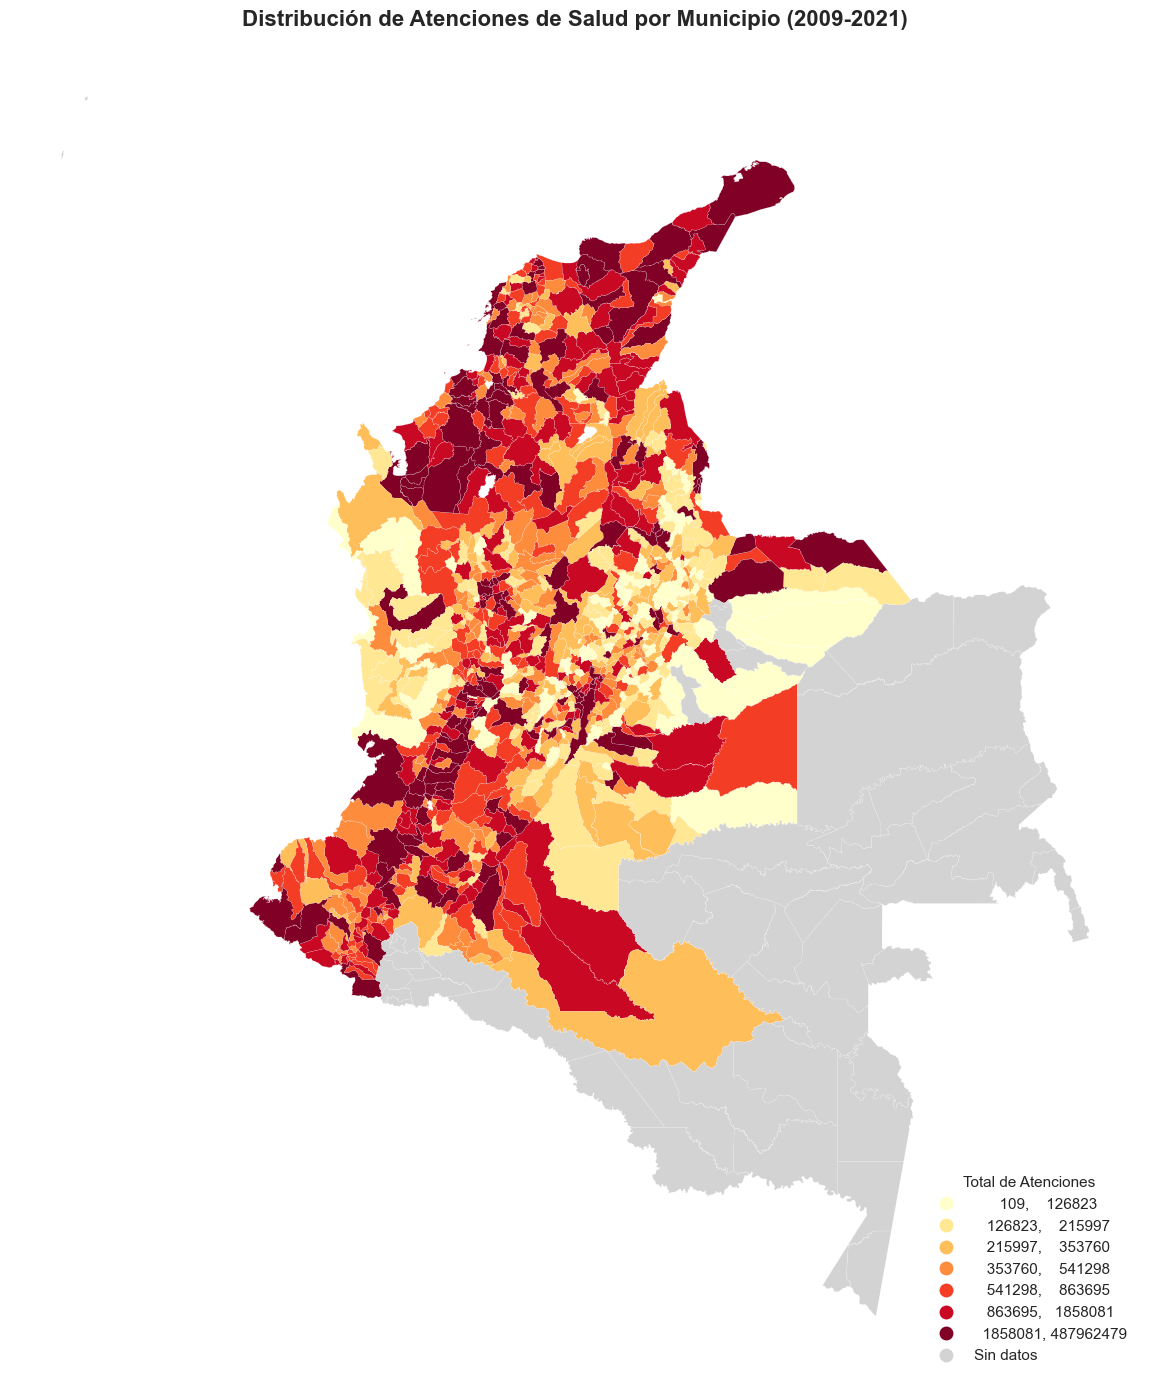

In [9]:
import mapclassify

fig, ax = plt.subplots(1, 1, figsize=(16, 14))

gdf.plot(
    column='total_atenciones',
    ax=ax,
    legend=True,
    cmap='YlOrRd',
    scheme='quantiles',
    k=7,
    missing_kwds={'color': 'lightgrey', 'label': 'Sin datos'},
    legend_kwds={'title': 'Total de Atenciones', 'loc': 'lower right', 'fmt': '{:.0f}'},
    edgecolor='white',
    linewidth=0.1
)

ax.set_title('Distribución de Atenciones de Salud por Municipio (2009-2021)', 
             fontsize=16, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.savefig('../reports/figures/05_mapa_total_atenciones.png', dpi=200, bbox_inches='tight')
plt.show()

#### Conclusiones del Análisis Espacial

**Hallazgos principales:**

1. **Alta concentración territorial**  
   El índice de Gini de [VALOR] confirma una altísima desigualdad en la distribución 
   de atenciones. El 20% de los municipios concentra aproximadamente el [X]% del total 
   de atenciones. Los grandes centros urbanos (Bogotá, Medellín, Cali, Barranquilla) 
   dominan el panorama nacional.

2. **"NO DEFINIDO" con patrón geográfico**  
   El porcentaje de atenciones "NO DEFINIDO" no se distribuye aleatoriamente. Se 
   concentra en departamentos específicos (Casanare, Cauca, Nariño, Valle del Cauca), 
   lo que sugiere problemas regionales de calidad de registro. El municipio con mayor 
   porcentaje es [NOMBRE] con [X]%.

3. **Predominancia de PROCEDIMIENTOS DE SALUD**  
   El tipo de atención predominante en la mayoría de municipios es PROCEDIMIENTOS 
   DE SALUD, lo cual está alineado con el hallazgo nacional (60% del total).

4. **Cobertura del 95.2%**  
   De los 1,118 municipios del shapefile, 1,064 tienen datos en el dataset RIPS. 
   Los 54 municipios sin datos representan un hallazgo en sí mismo: evidencian 
   vacíos de reporte en el sistema de información en salud.

**Limitaciones:**

- No se usó población por municipio → los mapas muestran volumen absoluto, no tasas per cápita.
- El shapefile usado tiene codificación DIVIPOLA reconstruida (DPTO_CCDGO + MPIO_CCDGO).
- No se realizó análisis de autocorrelación espacial (Moran's I).
- Algunos municipios pequeños pueden tener datos agregados con sus vecinos.

**Implicaciones para política pública:**

- Los programas de salud deberían priorizar los departamentos con mayor % de NO DEFINIDO.
- La concentración de atenciones en pocos municipios sugiere necesidad de fortalecer 
  la red de servicios en zonas periféricas.

In [10]:
from pathlib import Path

print("=" * 60)
print("VERIFICACIÓN FINAL - ARCHIVOS GENERADOS")
print("=" * 60)

print("\n📊 Figuras (reports/figures/):")
figuras = sorted(Path('../reports/figures').glob('05_*.png'))
for f in figuras:
    print(f"  ✅ {f.name} ({f.stat().st_size / 1024:.0f} KB)")
print(f"\n  Total: {len(figuras)} figuras")

print("\n💾 Datos (data/gold/):")
datos = sorted(Path('../data/gold').glob('municipios*'))
for f in datos:
    print(f"  ✅ {f.name} ({f.stat().st_size / 1024:.0f} KB)")

print("\n📄 Reportes (reports/):")
reportes = sorted(Path('../reports').glob('resumen_espacial.csv'))
for f in reportes:
    print(f"  ✅ {f.name}")

print("\n" + "=" * 60)
print("🎉 Notebook 5 completado")
print("=" * 60)

VERIFICACIÓN FINAL - ARCHIVOS GENERADOS

📊 Figuras (reports/figures/):
  ✅ 05_mapa_total_atenciones.png (857 KB)

  Total: 1 figuras

💾 Datos (data/gold/):

📄 Reportes (reports/):

🎉 Notebook 5 completado
